# Лабораторная работа 2
Выполнила студентка группы 6401 Иванова Дарья

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between my scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between my scores and correct scores:
3.680272118306016e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between my loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between my loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 3.865112e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738420e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


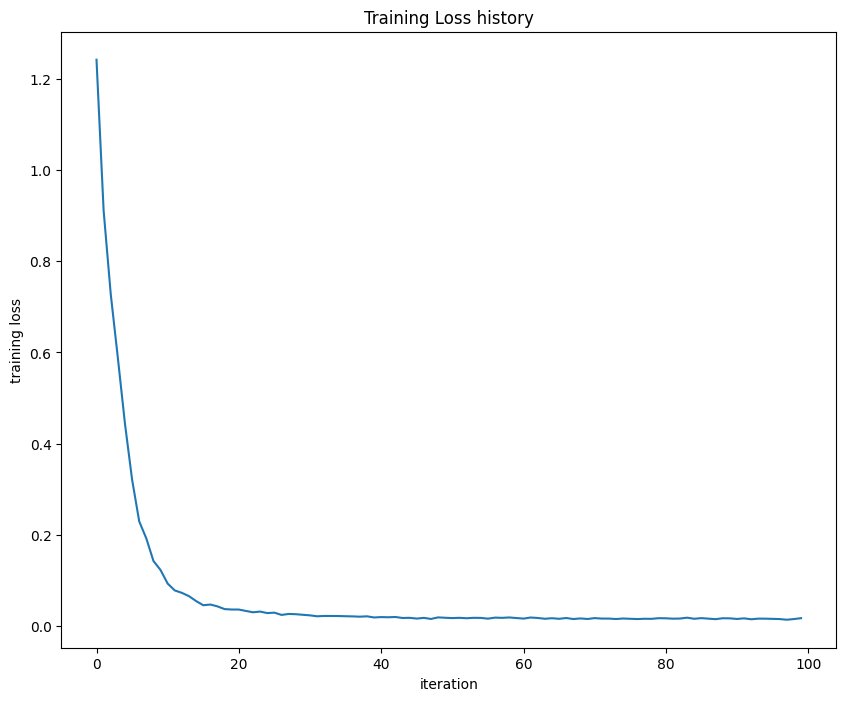

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

X_train — обучающая выборка, то есть признаки объектов, на которых сеть учится.

y_train — правильные ответы для обучающей выборки.

X_val — валидационная выборка, нужна для контроля качества модели на данных, которые не участвуют в обновлении весов.

y_val — правильные ответы для валидационной выборки.

num_iters=1000 — количество итераций обучения; то есть 1000 раз сеть берет батч, считает ошибку и обновляет параметры.

batch_size=200 — размер мини-батча; на каждой итерации сеть обучается не на всей обучающей выборке сразу, а на случайных 200 объектах.

learning_rate=1e-4 — скорость обучения, то есть шаг, с которым обновляются веса; если он слишком большой, обучение может быть нестабильным. Если слишком маленький, сеть будет учиться очень медленно.

learning_rate_decay=0.95 — коэффициент уменьшения скорости обучения; после каждой эпохи learning_rate умножается на 0.95, то есть постепенно уменьшается. Это нужно, чтобы в начале сеть делала более крупные шаги, а потом — более аккуратные.

reg=0.25 — коэффициент L2-регуляризации; он добавляет штраф за слишком большие веса и помогает бороться с переобучением.

verbose=True — печатать промежуточную информацию в процессе обучения; например, значение функции потерь через определенное число итерац

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

mean_image = np.mean(X_train, axis=0)
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1077, 64)
y_train shape: (1077,)
X_val shape: (360, 64)
y_val shape: (360,)
X_test shape: (360, 64)
y_test shape: (360,)


In [8]:
input_size = X_train.shape[1] 
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302594
iteration 100 / 1000: loss 2.302595
iteration 200 / 1000: loss 2.302594
iteration 300 / 1000: loss 2.302595
iteration 400 / 1000: loss 2.302592
iteration 500 / 1000: loss 2.302597
iteration 600 / 1000: loss 2.302595
iteration 700 / 1000: loss 2.302594
iteration 800 / 1000: loss 2.302593
iteration 900 / 1000: loss 2.302594
Validation accuracy:  0.15833333333333333


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

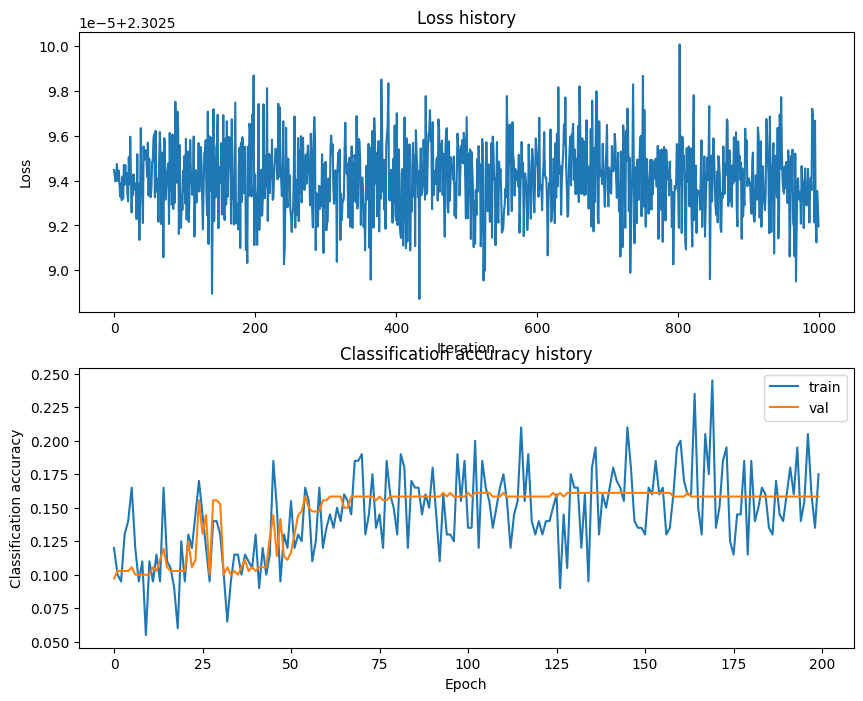

In [9]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

In [10]:
print(X_train.shape)
print(net.params['W1'].shape)

(1077, 64)
(64, 50)


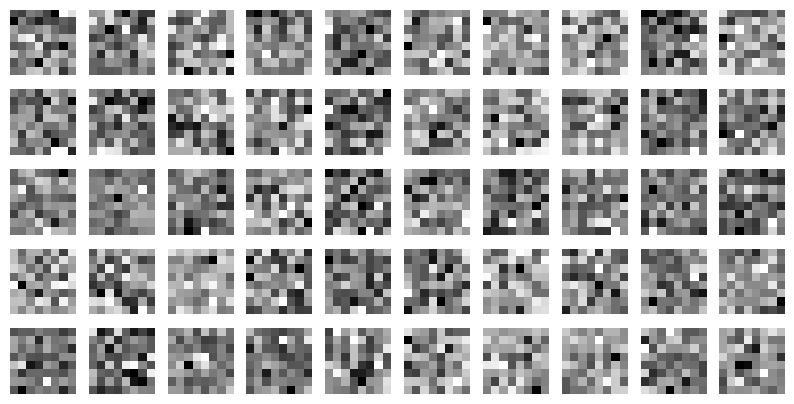

In [11]:
def show_net_weights(net):
    W1 = net.params['W1']  
    W1 = W1.T.reshape(-1, 8, 8)

    fig, axes = plt.subplots(5, 10, figsize=(10, 5))
    for i, ax in enumerate(axes.flat):
        if i < W1.shape[0]:
            ax.imshow(W1[i], cmap='gray')
        ax.axis('off')
    plt.show()

show_net_weights(net)

In [12]:
num_classes = 10

results = {}
best_val_acc = -1
best_net = None
best_stats = None
best_params = None

hidden_size_list = [100, 200, 300]
learning_rate_list = [0.05, 0.1, 0.2]
reg_list = [0.0, 1e-4, 1e-3]
learning_rate_decay_list = [1.0, 0.995, 0.99]
batch_size_list = [32, 64]
num_iters_list = [2000, 3000]

for hidden_size in hidden_size_list:
    for learning_rate in learning_rate_list:
        for reg in reg_list:
            for learning_rate_decay in learning_rate_decay_list:
                for batch_size in batch_size_list:
                    for num_iters in num_iters_list:
                        net = TwoLayerNet(input_size, hidden_size, num_classes)

                        stats = net.train(
                            X_train, y_train,
                            X_val, y_val,
                            num_iters=num_iters,
                            batch_size=batch_size,
                            learning_rate=learning_rate,
                            learning_rate_decay=learning_rate_decay,
                            reg=reg,
                            verbose=False
                        )

                        train_acc = (net.predict(X_train) == y_train).mean()
                        val_acc = (net.predict(X_val) == y_val).mean()

                        params = {
                            'hidden_size': hidden_size,
                            'learning_rate': learning_rate,
                            'reg': reg,
                            'learning_rate_decay': learning_rate_decay,
                            'batch_size': batch_size,
                            'num_iters': num_iters
                        }

                        results[str(params)] = {
                            'train_acc': train_acc,
                            'val_acc': val_acc
                        }

                        print(
                            'hidden_size=%d, lr=%g, reg=%g, decay=%.2f, batch=%d, iters=%d -> train=%.4f, val=%.4f'
                            % (
                                hidden_size,
                                learning_rate,
                                reg,
                                learning_rate_decay,
                                batch_size,
                                num_iters,
                                train_acc,
                                val_acc
                            )
                        )

                        if val_acc > best_val_acc:
                            best_val_acc = val_acc
                            best_net = net
                            best_stats = stats
                            best_params = params

print('\nЛучшая val accuracy:', best_val_acc)
print('Лучшие параметры:', best_params)

hidden_size=100, lr=0.05, reg=0, decay=1.00, batch=32, iters=2000 -> train=1.0000, val=0.9750
hidden_size=100, lr=0.05, reg=0, decay=1.00, batch=32, iters=3000 -> train=1.0000, val=0.9722
hidden_size=100, lr=0.05, reg=0, decay=1.00, batch=64, iters=2000 -> train=1.0000, val=0.9694
hidden_size=100, lr=0.05, reg=0, decay=1.00, batch=64, iters=3000 -> train=1.0000, val=0.9694
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=32, iters=2000 -> train=1.0000, val=0.9694
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=32, iters=3000 -> train=1.0000, val=0.9667
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=64, iters=2000 -> train=1.0000, val=0.9694
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=64, iters=3000 -> train=1.0000, val=0.9694
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=32, iters=2000 -> train=1.0000, val=0.9667
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=32, iters=3000 -> train=1.0000, val=0.9667
hidden_size=100, lr=0.05, reg=0, decay=0.99, batch=64, iters

In [13]:
test_acc = (best_net.predict(X_test) == y_test).mean()
print('Test accuracy:', test_acc)

Test accuracy: 0.9722222222222222


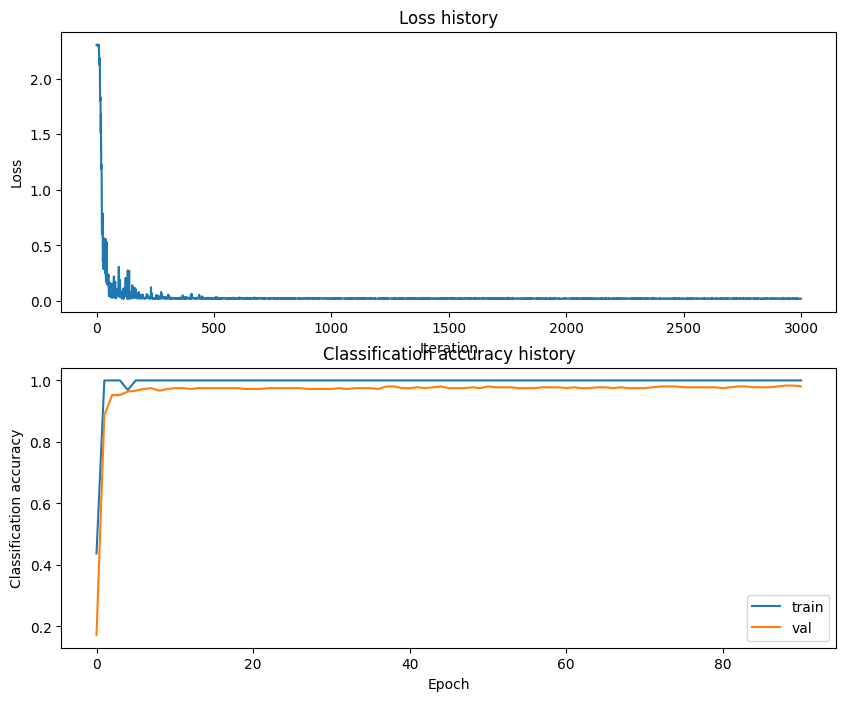

In [14]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

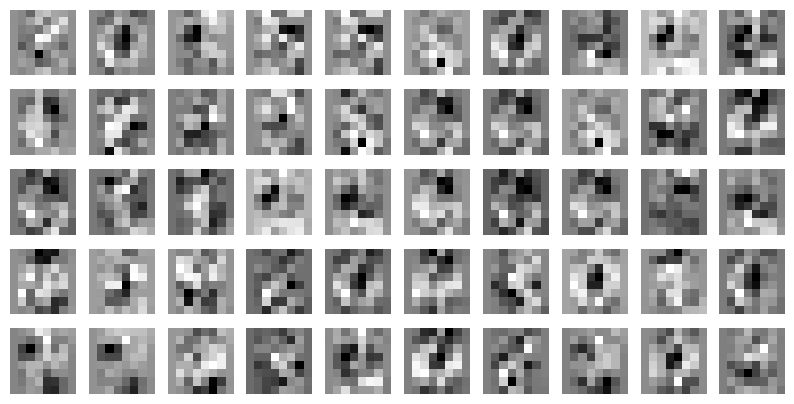

In [15]:
show_net_weights(best_net)

Сделайте выводы по результатам работы. 

Была реализована двухслойная полносвязная нейронная сеть с функциями ReLU и softmax.

Далее сеть была обучена на  данных load_digits. На начальных параметрах качество классификации было низким, однако после подбора гиперпараметров результат удалось значительно улучшить. В ходе экспериментов изменялись размер скрытого слоя, скорость обучения, коэффициент регуляризации, коэффициент уменьшения скорости обучения, размер мини-батча, число итераций обучения.

Лучшие параметры: hidden_size - 200, learning_rate - 0.2, reg - 0.001, learning_rate_decay - 0.995, batch_size - 32, num_iters - 3000

В результате лучшая модель показала validation accuracy = 0.9833, а на тестовой выборке test accuracy = 0.9722. Подбор гиперпараметров сильно повлиял на качество работы сети и позволил получить значительно лучший результат по сравнению с исходной моделью.